In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df = pd.read_csv('../../../data/interim/punjab_cleaned_groundwater.csv')

C:\Users\raj vardhan jha\AppData\Local\Temp\ipykernel_13632\2700469795.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../../../data/interim/punjab_cleaned_groundwater.csv')


In [3]:
for i, col in enumerate(df.columns):
    print(i, col)

0 Station
1 State
2 District LGD Code
3 District
4 Block
5 Latitude
6 Longitude
7 Data Acquisition Time
8 Groundwater Level Telemetry Quadridaily (meter)


In [5]:
#Since datetime is lost after saving as CSV so we will again convert it 

df['Data Acquisition Time'] = pd.to_datetime(df['Data Acquisition Time']) 

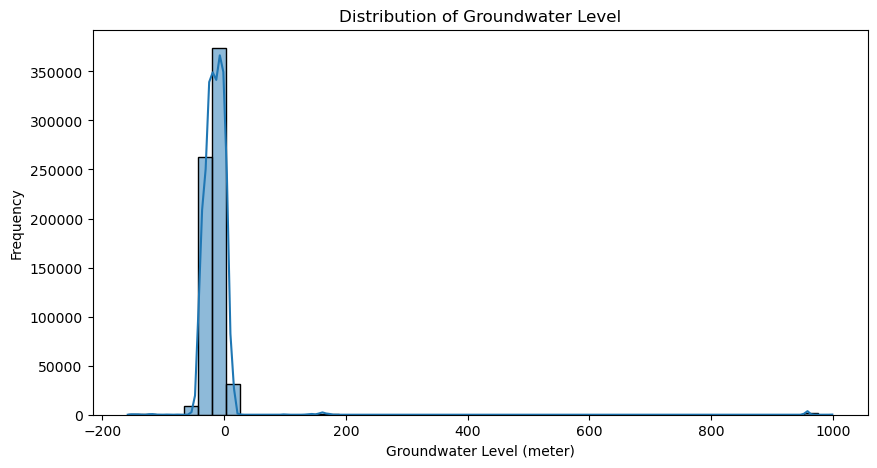

In [9]:
#we will plot a histogram for groundwater level which will give us info about the range of groundwater level across the state and what is the common frequency range

plt.figure(figsize=(10,5))

sns.histplot(df['Groundwater Level Telemetry Quadridaily (meter)'], bins=50, kde=True) 

plt.title('Distribution of Groundwater Level')
plt.xlabel('Groundwater Level (meter)')
plt.ylabel('Frequency') 

plt.show()

as this graph also includes extreme outliers in groundwater level so it's very unclear to read the graph thats why we'll create a filtered graph without extreme outliers

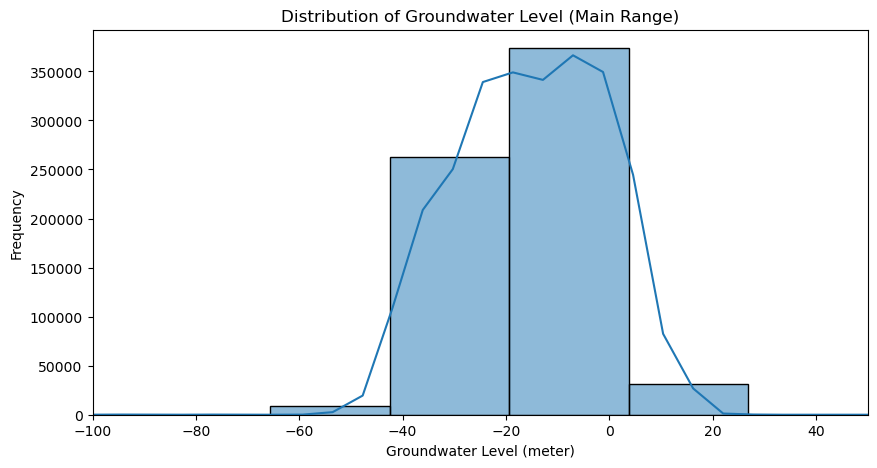

In [8]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Groundwater Level Telemetry Quadridaily (meter)"],
    bins=50,
    kde=True
)

plt.xlim(-100, 50)

plt.title("Distribution of Groundwater Level (Main Range)")
plt.xlabel("Groundwater Level (meter)")
plt.ylabel("Frequency")

plt.show()

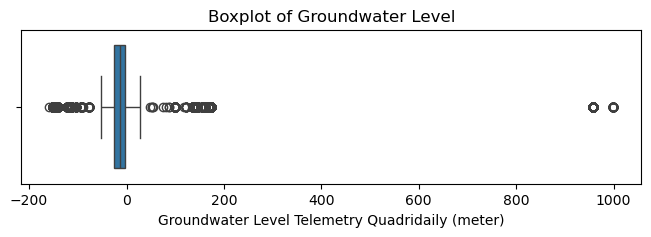

In [10]:
# now we will plot boxplot for outlier detectio: 

plt.figure(figsize=(8,2))

sns.boxplot(x= df['Groundwater Level Telemetry Quadridaily (meter)'])

plt.title('Boxplot of Groundwater Level')

plt.show()

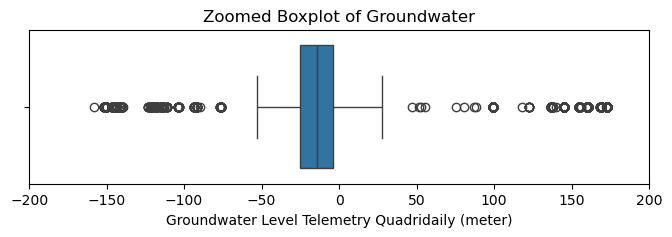

In [11]:
plt.figure(figsize=(8,2))
sns.boxplot(x= df['Groundwater Level Telemetry Quadridaily (meter)'])
plt.xlim(-200,200)
plt.title('Zoomed Boxplot of Groundwater')
plt.show()

### Boxplot Analysis (Outlier Detection)

The boxplot provides a summary of the distribution of groundwater level measurements and helps identify potential outliers in the dataset.

**Observations:**
- The median groundwater level lies close to the center of the distribution, indicating that most observations are concentrated around this range.
- The interquartile range (IQR), represented by the box, contains the middle 50% of the groundwater level observations.
- Several observations lie beyond the whiskers on both the negative and positive sides, indicating the presence of outliers.
- The dataset contains more extreme negative values than positive values, suggesting greater variability in certain monitoring locations or time periods.
- These outliers are expected in groundwater datasets and may result from natural hydrogeological variations, seasonal recharge, intensive groundwater extraction, measurement conditions, or localized environmental factors.

**Conclusion:**
The detected outliers were retained in the dataset because they likely represent genuine groundwater conditions rather than data entry errors. Preserving these observations ensures that important real-world variations are not lost and allows machine learning models to learn from the complete range of groundwater behavior.

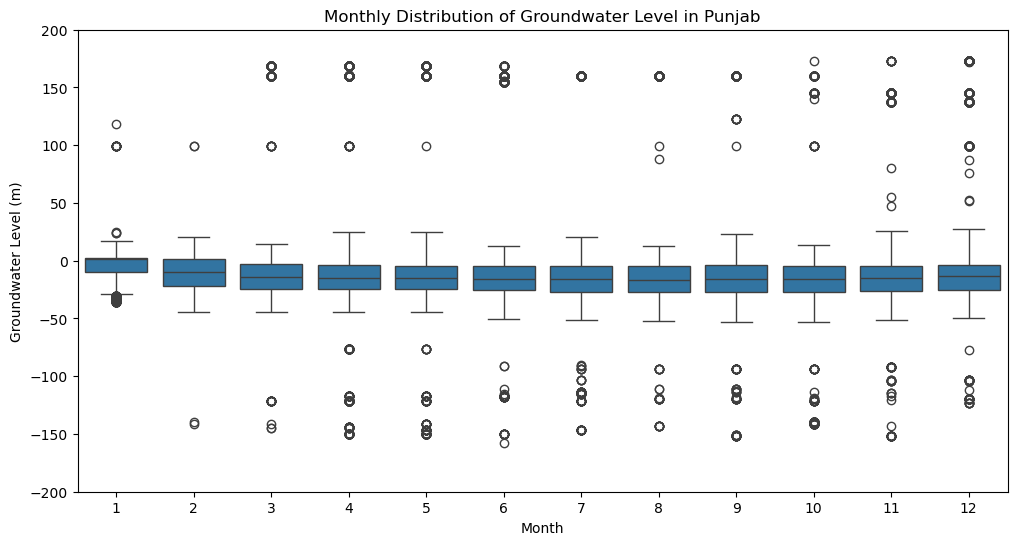

In [13]:
# Monthly Groundwater Trend (Seasonality): 

df['Month'] = df['Data Acquisition Time'].dt.month 

plt.figure(figsize=(12,6))
sns.boxplot(x='Month', y='Groundwater Level Telemetry Quadridaily (meter)', data=df)
plt.ylim(-200,200)
plt.title('Monthly Distribution of Groundwater Level in Punjab')
plt.xlabel('Month')
plt.ylabel('Groundwater Level (m)')

plt.show()

### Monthly Distribution of Groundwater Level

The monthly boxplot illustrates the distribution of groundwater levels across all monitoring stations in Punjab for each month of the year. The y-axis was limited to **-200 m to 200 m** to improve readability by reducing the influence of extreme outliers.

**Observations:**
- The median groundwater level remains relatively stable across all twelve months, indicating no substantial month-to-month change in the central tendency.
- The interquartile range (IQR) is similar for most months, suggesting that groundwater variability remains fairly consistent throughout the year.
- Most groundwater level observations lie approximately between **-50 m and +20 m**, while values beyond this range appear as outliers.
- Extreme positive and negative outliers are observed in every month, representing unusually shallow or deep groundwater measurements at certain monitoring stations.
- Months towards the end of the year (October–December) exhibit a relatively higher number of positive outliers, although the overall monthly distributions remain similar.
- No pronounced seasonal shift is observed in the median or spread of groundwater levels, indicating that spatial factors such as district characteristics, groundwater extraction, and local hydrogeological conditions likely have a greater influence than the month alone.

**Conclusion:**
The monthly distributions suggest that groundwater levels in Punjab remain relatively stable throughout the year, with variability primarily driven by localized conditions rather than strong seasonal fluctuations. The identified outliers were retained as they likely represent genuine groundwater conditions and are valuable for subsequent machine learning analysis.

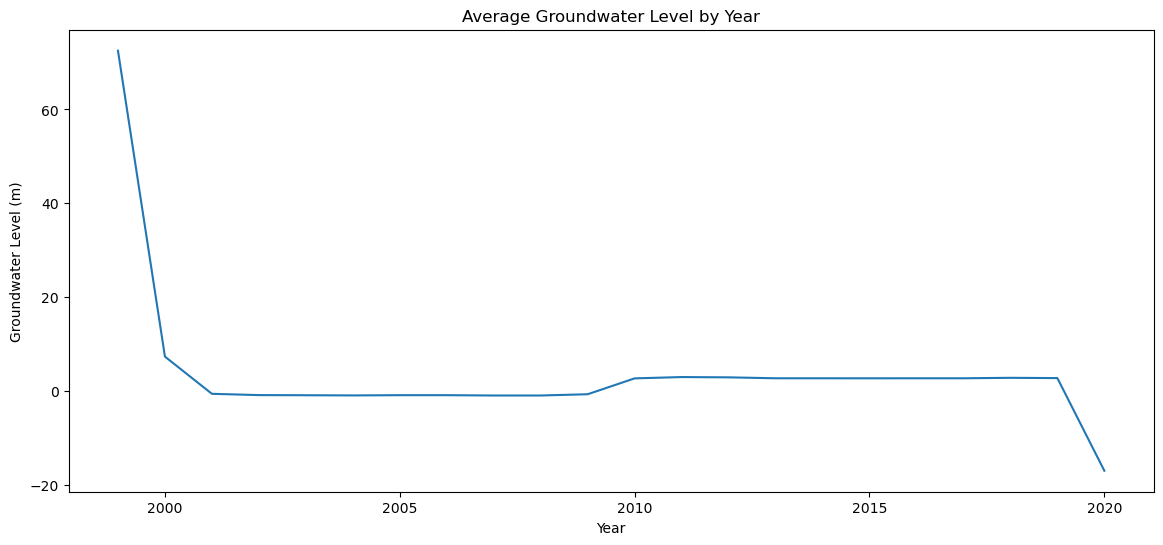

In [15]:
#Lineplot for Year-wise Trend: 

df['Year'] = df['Data Acquisition Time'].dt.year

plt.figure(figsize=(14,6))

sns.lineplot(
    data=df,
    x='Year',
    y='Groundwater Level Telemetry Quadridaily (meter)',
    estimator='mean',
    errorbar=None
)

plt.title("Average Groundwater Level by Year")
plt.xlabel("Year")
plt.ylabel("Groundwater Level (m)")

plt.show()

In [16]:
df.groupby('Year').size()

Year
1999        94
2000      5387
2001      6475
2002      6044
2003      5844
2004      5857
2005      5844
2006      5844
2007      5840
2008      5856
2009      5897
2010      7671
2011      8766
2012      8838
2013     10220
2014     10222
2015     10312
2016     10248
2017     10220
2018     10221
2019     10229
2020    525366
dtype: int64

### Year-wise Average Groundwater Level

The line chart illustrates the average groundwater level recorded each year in Punjab over the study period.

**Observations:**
- The average groundwater level is exceptionally high in **1999**, followed by a sharp decline in the subsequent years.
- Between **2001 and 2009**, the yearly average remains relatively stable, indicating consistent groundwater conditions during this period.
- From **2010 to 2019**, the average groundwater level shows a slight increase and remains nearly constant.
- A noticeable decrease is observed in **2020**, where the average groundwater level is substantially lower than in previous years.

**Interpretation:**
- The unusually high average observed in **1999** should be interpreted cautiously, as only **94 observations** are available for that year, making it less representative of statewide groundwater conditions.
- The sharp change in **2020** coincides with a substantial increase in the number of observations due to telemetry-based quadridaily measurements. Since the data collection methodology and sampling frequency differ significantly from earlier years, direct comparison with previous years should be made with caution.
- Excluding these exceptional years, the average groundwater levels remain relatively stable over most of the study period, indicating no pronounced long-term trend in the yearly averages alone.

In [17]:
#District-wise Average Groundwater Level: 

district_avg = (
    df.groupby('District')
    ['Groundwater Level Telemetry Quadridaily (meter)']
    .mean()
    .sort_values()
) 

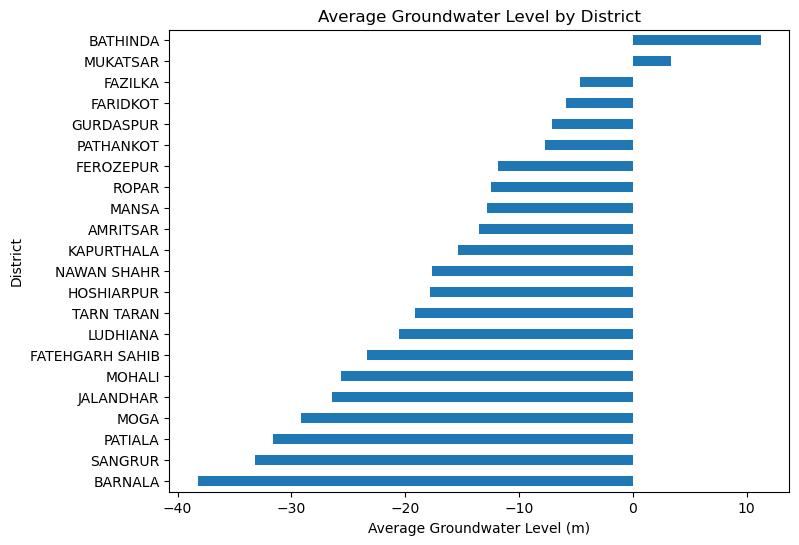

In [19]:
plt.figure(figsize=(8,6))

district_avg.plot(kind='barh')

plt.title("Average Groundwater Level by District")
plt.xlabel("Average Groundwater Level (m)")
plt.ylabel("District")

plt.show()

### District-wise Average Groundwater Level

The horizontal bar chart compares the average groundwater level across different districts in Punjab. It highlights the spatial variation in groundwater conditions throughout the state.

**Observations:**
- Significant differences in average groundwater levels are observed among districts, indicating considerable spatial variability.
- **Barnala** records the lowest average groundwater level, followed by **Sangrur**, **Patiala**, and **Moga**, suggesting comparatively deeper groundwater levels in these districts.
- **Bathinda** exhibits the highest average groundwater level, indicating relatively shallower groundwater or a higher water level relative to the reference datum.
- Most districts have average groundwater levels between **-10 m and -30 m**, reflecting moderate regional variation.
- The observed differences are likely influenced by local hydrogeological conditions, rainfall patterns, irrigation intensity, groundwater extraction, and land-use practices.

**Interpretation of Negative Values:**
The groundwater level measurements are referenced to a fixed datum used by the telemetry monitoring system. Therefore, negative values do **not** indicate that groundwater is above the ground surface. Instead, they indicate that the measured groundwater level lies below the reference datum. More negative values generally correspond to deeper groundwater levels relative to that reference.

**Conclusion:**
The plot demonstrates substantial spatial variation in groundwater levels across Punjab. These regional differences suggest that geographical location plays an important role in groundwater dynamics and justify the inclusion of spatial features such as **District**, **Latitude**, and **Longitude** in groundwater level prediction models.

### NOTE: In groundwater monitoring, there are generally two conventions:

Depth Below Ground Level (mbgl) → Always positive (e.g., 15 m below ground).
Water Level Elevation relative to a Reference Datum (such as Mean Sea Level or sensor zero) → Can be positive or negative.

Since your dataset contains both positive and negative values, it is almost certainly using the second convention. A negative value simply means the measured water level is below the chosen reference datum, not above the ground surface

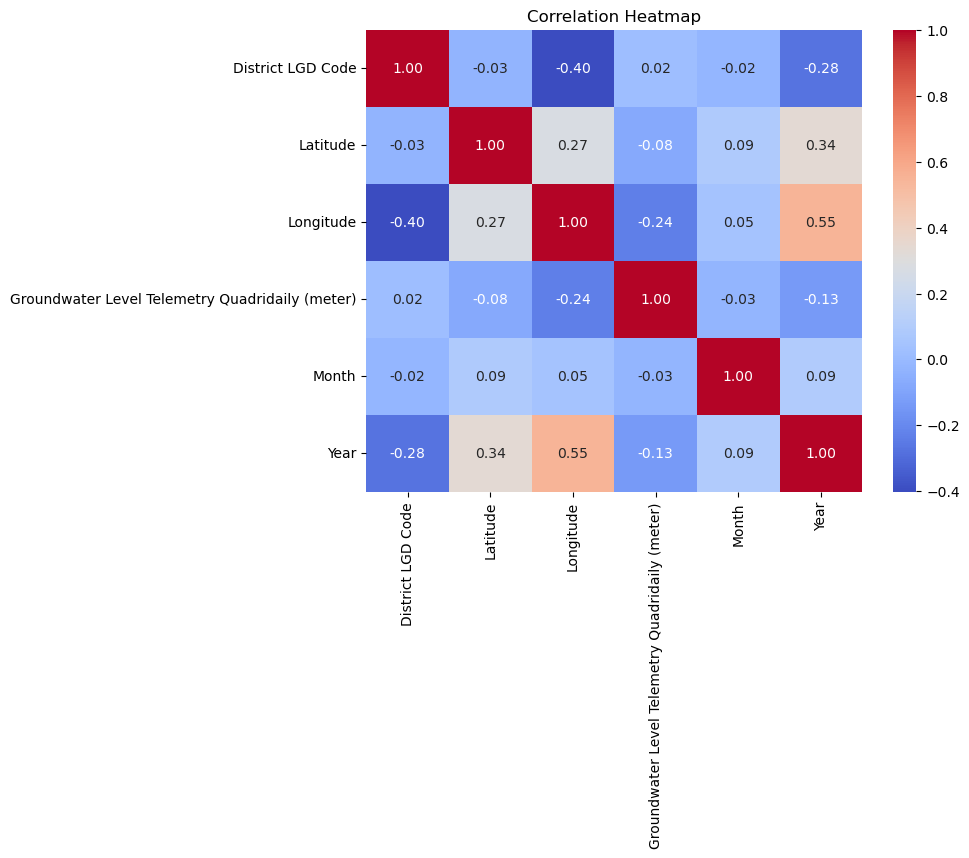

In [21]:
# Correlation Heatmap: 

numeric_df = df.select_dtypes(include='number') 

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

### Correlation Analysis

The correlation heatmap illustrates the Pearson correlation coefficients among the numerical variables in the dataset. Correlation values range from **-1** (strong negative relationship) to **+1** (strong positive relationship), while values close to **0** indicate little or no linear relationship.

**Observations:**
- The groundwater level exhibits **weak linear correlations** with all numerical variables, including **Latitude (-0.08)**, **Longitude (-0.24)**, **Month (-0.03)**, and **Year (-0.13)**.
- The weak correlations suggest that groundwater levels are influenced by multiple interacting environmental and geographical factors rather than any single numerical variable.
- **Longitude** and **Year** show the strongest positive correlation (**0.55**), indicating that monitoring locations may have changed or expanded over time.
- **Latitude** and **Year** also exhibit a moderate positive correlation (**0.34**), which may reflect variations in the spatial distribution of monitoring stations across different years.
- **Month** has an almost negligible correlation with groundwater level, indicating the absence of a strong linear seasonal pattern at the state level.
- The **District LGD Code** is an identifier rather than a continuous measurement; therefore, its correlations do not have meaningful physical interpretations.

**Conclusion:**
The correlation analysis indicates that groundwater level cannot be explained by any single numerical feature through a simple linear relationship. This suggests that more advanced machine learning models capable of capturing nonlinear relationships and interactions among multiple variables are better suited for groundwater level prediction.

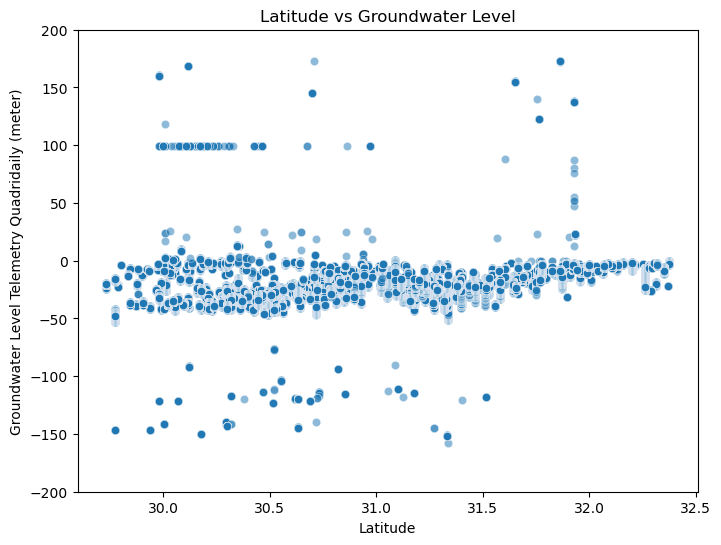

In [25]:
#Scatter Plot (Latitude vs Groundwater): 

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Latitude',
    y='Groundwater Level Telemetry Quadridaily (meter)',
    alpha=0.5
)

plt.ylim(-200,200)

plt.title("Latitude vs Groundwater Level")

plt.show()

### Latitude vs Groundwater Level

The scatter plot illustrates the relationship between **latitude** and **groundwater level** across monitoring stations in Punjab. The y-axis was limited to **-200 m to 200 m** to improve readability and reduce the visual influence of extreme outliers.

**Observations:**
- The data points are widely scattered, indicating **no strong linear relationship** between latitude and groundwater level.
- Most groundwater level measurements are concentrated between **-50 m and 0 m** across the entire latitude range.
- Several positive and negative outliers are observed throughout the plot, suggesting localized groundwater conditions rather than latitude-specific effects.
- No distinct increasing or decreasing trend is visible, indicating that groundwater levels remain relatively consistent across different latitudes.
- A few latitude ranges contain denser clusters of observations due to the presence of multiple monitoring stations in those regions.

**Conclusion:**
Latitude alone has a weak influence on groundwater level, which is consistent with the correlation analysis showing a very weak negative correlation (**r = -0.08**). This suggests that groundwater levels are influenced by multiple interacting factors, including longitude, district, geological characteristics, groundwater extraction, and recharge conditions, rather than latitude alone.

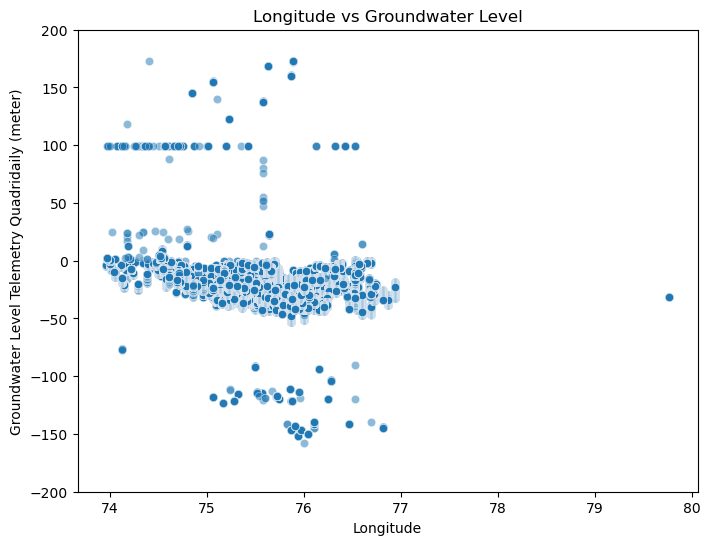

In [27]:
#Scatter Plot (Longitude vs Groundwater): 

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Longitude',
    y='Groundwater Level Telemetry Quadridaily (meter)',
    alpha=0.5
)

plt.ylim(-200,200)

plt.title("Longitude vs Groundwater Level")

plt.show()

### Longitude vs Groundwater Level

The scatter plot illustrates the relationship between **longitude** and **groundwater level** across monitoring stations in Punjab. The y-axis was limited to **-200 m to 200 m** to improve readability by reducing the visual influence of extreme outliers.

**Observations:**
- The data points are widely scattered, indicating **no strong linear relationship** between longitude and groundwater level.
- Most groundwater level measurements are concentrated between **-50 m and 0 m** across the majority of the longitude range.
- Several positive and negative outliers are present, representing localized groundwater conditions rather than a systematic longitudinal trend.
- Most observations are clustered between **74°E and 77°E**, reflecting the geographical distribution of monitoring stations within Punjab.
- A few isolated observations are present outside the main cluster and may correspond to unique monitoring locations or exceptional measurements.

**Conclusion:**
Longitude exhibits only a weak linear relationship with groundwater level, consistent with the correlation analysis (**r = -0.24**). This indicates that groundwater variability cannot be explained by longitude alone and is more likely governed by a combination of geographical, geological, climatic, and anthropogenic factors. Consequently, longitude should be considered alongside other spatial and temporal features when developing groundwater level prediction models.

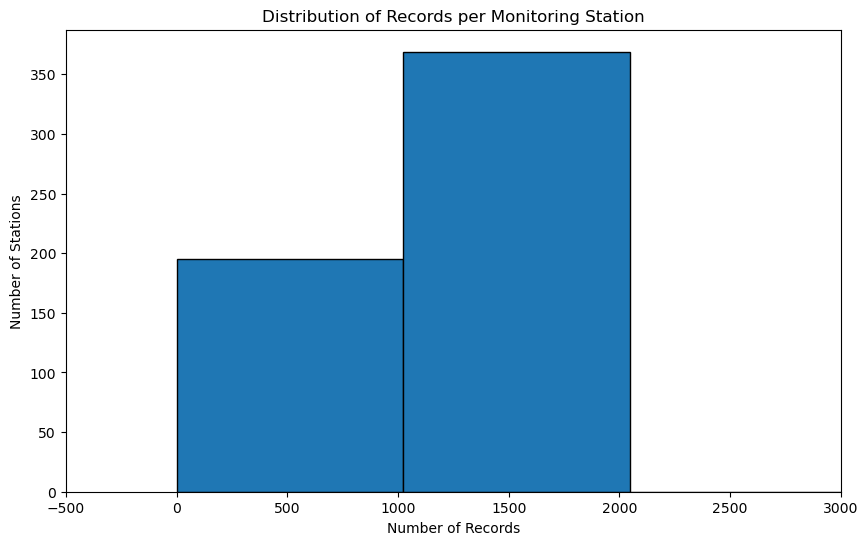

In [32]:
#Station-wise Data Count: 

plt.figure(figsize=(10,6))

plt.hist(station_count, bins=30, edgecolor='black')

plt.xlim(-500,3000)

plt.title("Distribution of Records per Monitoring Station")
plt.xlabel("Number of Records")
plt.ylabel("Number of Stations")

plt.show()

### Distribution of Records per Monitoring Station

The histogram illustrates the distribution of the number of groundwater observations recorded by each monitoring station in Punjab.

**Observations:**
- Most monitoring stations contain between **1,000 and 2,000 observations**, indicating that the majority of stations have a substantial historical record.
- A smaller number of stations have fewer than **1,000 observations**, which may be due to later installation, temporary telemetry interruptions, maintenance activities, or missing measurements.
- The distribution suggests that the monitoring network is reasonably balanced, with no evidence that a small number of stations dominate the dataset.
- The availability of a large number of observations for most stations makes the dataset suitable for time-series analysis and feature engineering.

**Conclusion:**
The monitoring stations generally provide sufficient historical groundwater observations for analysis and predictive modeling. Although a few stations contain fewer records, the overall distribution indicates good data coverage across the monitoring network, supporting the development of reliable machine learning models.

In [33]:
station_count.describe()

count      571.000000
mean      1193.161121
std       2701.419859
min          1.000000
25%        523.500000
50%       1163.000000
75%       1261.000000
max      30686.000000
Name: count, dtype: float64

In [34]:
station_count.sort_values().head(10)

Station
PB_Ferozpur_Guru Har Sahai_Sawah Wala     1
PB_Mukatsar_Lambi_Bhitti Wali             1
PB_Ferozpur_Ghall Khurd_Lohgarh           1
PB_Mukatsar_Lambi_Kutean Wali             1
PB_Moga_Moga_kokri kalan                  1
PB_Ferozpur_Ghall Khurd_Baghe Ke Pipal    1
PB_Mukatsar_Malout_Karamgarh              1
PB_Mukatsar_Malout_Sarawan                1
PB_Amritsar_Jandiala_jandiala             1
PB_Fazilka_Khuuain Sarwar_Kathera         1
Name: count, dtype: int64

In [35]:
station_count = df['Station'].value_counts()

print("Stations with < 5 records :", (station_count < 5).sum())
print("Stations with < 10 records:", (station_count < 10).sum())
print("Stations with < 20 records:", (station_count < 20).sum())
print("Stations with < 50 records:", (station_count < 50).sum())
print("Stations with < 100 records:", (station_count < 100).sum())

Stations with < 5 records : 49
Stations with < 10 records: 58
Stations with < 20 records: 68
Stations with < 50 records: 73
Stations with < 100 records: 89


### Monitoring Station Record Statistics

The descriptive statistics of the monitoring station record counts provide insights into the availability of groundwater observations across the monitoring network.

**Observations:**
- The dataset contains groundwater observations from **571 monitoring stations**.
- On average, each station contains approximately **1,193 observations**, while the median is **1,163 observations**, indicating that many stations have comparable amounts of historical data.
- The number of observations per station varies considerably, ranging from **1** to **30,686** records.
- The relatively high standard deviation (**2,701**) indicates substantial variation in record availability across monitoring stations.
- A small number of stations contain only a single observation, whereas a few stations contribute a significantly larger number of records than the majority.

**Conclusion:**
Most monitoring stations provide sufficient historical data for temporal analysis and feature engineering. However, a small number of stations contain very limited observations, which may not be suitable for generating lag or rolling statistical features. These stations will be evaluated during the preprocessing stage before model development.

### Monitoring Station Record Statistics

The descriptive statistics of the monitoring station record counts provide insights into the availability of groundwater observations across the monitoring network.

**Observations:**
- The dataset contains groundwater observations from **571 monitoring stations**.
- On average, each station contains approximately **1,193 observations**, while the median is **1,163 observations**, indicating that many stations have comparable amounts of historical data.
- The number of observations per station varies considerably, ranging from **1** to **30,686** records.
- The relatively high standard deviation (**2,701**) indicates substantial variation in record availability across monitoring stations.
- A small number of stations contain only a single observation, whereas a few stations contribute a significantly larger number of records than the majority.

**Conclusion:**
Most monitoring stations provide sufficient historical data for temporal analysis and feature engineering. However, a small number of stations contain very limited observations, which may not be suitable for generating lag or rolling statistical features. These stations will be evaluated during the preprocessing stage before model development.